In [1]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb


# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


In [2]:
root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24",
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29",
                    ]


session_id = example_session_ids[1]

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr


In [3]:
# access the session data with pynwb - should take about a minute

session = pynwb.read_nwb(nwb_path)

# Quick reference of the NWB file structure
# Important groups include: units, trials, intervals, and processing 
session

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.17525
2,14.19192
3,14.20858
,timestamps
id,
0,NaN
1,14.40125
2,14.41791


In [7]:
units_table = session.units.to_dataframe()
print('this session has %d units before quality control' % len(units_table))
units_table.head()

this session has 3577 units before quality control


,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,is_qc_pass,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.023644,369.640648,0.000134,NaN,NaN,266.759980,6150.0,3875.0,4875.0,0,5.901353,sua,0.72,False,20097906812,NaN,NaN,NaN,probeA,0.045512,16.4,3.436095,0.000197,True,False,0.0,0.000000,169.265511,0.005430,AV,0.940000,0.003616,1,1,26323.0,1,1,0.000520,-0.375402,0.692913,-172657.903480,1.230873e+06,0.000000,0.0,0.232128,0.010,15.445013,"[-360.36, -290.16, -339.3, -308.87997, -327.59...",40.0,AV,0.035558,0.000038,0.0,713655_2024-08-09_A-0,NaN,NaN,"[20.36006860549634, 20.675801047260247, 20.701...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14018...
1,0.267538,115.956440,0.000014,NaN,NaN,84.240000,6150.0,3850.0,4850.0,1,3.396367,sua,0.96,False,20097906812,NaN,NaN,NaN,probeA,0.023075,9.6,2.835761,0.000210,False,False,9.0,0.048698,84.445991,0.483533,AV,0.546667,0.022550,1,1,21724.0,2,2,0.000430,-0.506552,0.992126,-66172.145988,3.955176e+05,0.016367,2.0,0.052200,0.045,5.555777,"[-93.6, -86.579994, -107.64, -175.5, -79.56, -...",100.0,AV,0.027481,0.000000,0.0,713655_2024-08-09_A-1,NaN,NaN,"[20.299502109858143, 20.337768668467195, 20.35...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14018...
2,0.245425,130.590736,0.000014,0.248327,0.135620,86.579994,6150.0,3825.0,4850.0,2,4.327034,sua,0.82,False,20097906812,7.680075,27.356254,4.589439,probeA,0.025432,7.6,4.295152,0.000247,False,False,53.0,0.125005,102.396583,0.522438,AV,0.482201,0.010082,1,1,32904.0,6,6,0.000450,-0.537150,1.000000,-79395.038450,4.333844e+05,0.062070,17.0,0.047700,0.045,4.898145,"[-39.78, -63.179996, -23.4, -37.44, -42.12, -6...",120.0,AV,0.023371,0.000000,0.0,713655_2024-08-09_A-2,NaN,NaN,"[21.072399927339106, 21.876864322348617, 22.03...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14018...
3,0.093258,297.245514,0.000016,NaN,NaN,196.560000,6150.0,3825.0,4850.0,3,5.249897,sua,0.85,True,20097906812,7.515987,24.548646,3.918794,probeA,0.033764,11.0,4.390704,0.000167,True,True,3.0,0.006771,139.091580,0.032691,AV,0.865692,0.009278,1,1,33636.0,5,5,0.000423,-0.501085,1.000000,-180857.379447,1.266800e+06,0.006794,2.0,0.154244,0.010,11.379719,"[-226.98, -212.93999, -159.12, -133.37999, -23...",80.0,AV,0.022535,0.000030,0.0,713655_2024-08-09_A-3,NaN,NaN,"[21.589898466019914, 25.376921105508842, 26.38...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14018...
4,0.136946,102.880402,0.000222,0.514950,0.560272,56.159996,6100.0,3800.0,4850.0,4,3.126732,sua,0.63,False,20097906812,NaN,NaN,NaN,probeA,0.028388,3.0,0.562218,0.000413,False,False,2.0,0.275315,74.687850,1.688826,AV,0.315534,0.013454,1,2,4307.0,7,7,0.000393,-0.827439,1.000000,-77300.768984,4.390522e+05,0.000000,0.0,0.048807,0.230,3.235930,"[-53.82, -53.82, -46.8, -88.92, -100.619995, -...",100.0,AV,0.039703,0.000000,0.0,713655_2024-08-09_A-4,NaN,NaN,"[20.275168845237403, 20.52226814747514, 20.788...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x14018...


In [12]:
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

# MAX_ACTIVITY_DRIFT = 0.3        # low threshold
# MAX_ACTIVITY_DRIFT = 0.2        # moderate threshold
MAX_ACTIVITY_DRIFT = 0.1          # high threshold
# MAX_ACTIVITY_DRIFT = 0.05       # very high threshold

#low_drift_units = units_table[units_table.activity_drift < MAX_ACTIVITY_DRIFT]

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO) &
    (units_table.activity_drift < MAX_ACTIVITY_DRIFT)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

982 of 3577 units passed quality control


In [13]:
good_units.location.unique()

<StringArray>
[        'AV',         'AD',      'MOs6a',      'MOp6a',       'MOp5',
     'MOp2/3',       'SSs4',       'SSs5',   'SSp-bfd4', 'SSp-bfd2/3',
      'PERI5',       'ECT5',      'ECT6a',      'TEa6a',     'AUDv6a',
     'AUDp6a',      'AUDp5',     'AUDpo5',       'TEa5',       'TEa4',
     'TEa2/3',   'VISli2/3',        'LSr',         'CP',      'MOp6b',
        'LSc',       'MOs5',     'ACAd6a',     'MOs2/3']
Length: 29, dtype: str

In [14]:
#this_structure_units_table = good_units[good_units.structure == 'AUDp']
this_structure_units_table = good_units[good_units.structure.str.contains('AUD', case=False, na=False)]
print('%d good units in selected brain area)' % len(this_structure_units_table))


144 good units in selected brain area)


In [15]:
this_structure_units_table

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,is_qc_pass,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1168,0.037638,97.531204,0.000153,0.198888,0.187644,58.499996,8100.0,3700.0,1350.0,220,4.169599,sua,0.86,True,18005120322,NaN,NaN,NaN,probeC,0.026792,3.40,1.239951,0.000220,True,True,1.0,0.028301,150.073410,0.037583,AUDv6a,0.544872,0.002977,1,1,9499.0,136,904,0.000327,-0.640100,1.000000,-61163.944771,367571.122561,0.043392,1.0,0.105982,0.065,5.688648,"[-86.579994, -72.54, -74.88, -77.21999, -63.17...",120.0,AUDv,0.070534,0.000526,0.000000,713655_2024-08-09_C-220,222.760082,180.711275,"[21.989781519563575, 22.557942592740456, 22.69...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x14018...
1169,0.026351,104.794590,0.000347,0.224786,0.425012,77.219990,8150.0,3650.0,1350.0,221,5.043489,sua,0.76,True,18005120322,2.155963,10.100891,2.755691,probeC,0.025331,11.49,9.918434,0.000283,True,True,11.0,0.004865,133.949242,0.042519,AUDv6a,0.696078,0.003039,1,1,75983.0,141,909,0.000657,-0.375769,1.000000,-40628.053740,240054.423755,0.004655,7.0,0.125131,0.010,5.475848,"[-72.54, -77.21999, -74.88, -79.56, -72.54, -7...",120.0,AUDv,0.067620,0.000026,0.000000,713655_2024-08-09_C-221,93.506634,NaN,"[20.428263559220696, 20.712894090394496, 20.97...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x14018...
1171,0.056187,101.045849,0.000336,0.170150,0.151421,65.520000,8125.0,3700.0,1350.0,223,4.124557,sua,0.85,True,18005120322,NaN,NaN,NaN,probeC,0.044123,3.60,1.152623,0.000140,True,True,2.0,0.065503,113.672154,0.378748,AUDv6a,0.303846,0.008453,1,1,8830.0,137,905,0.000310,-0.505840,1.000000,-52337.086744,500343.617692,0.103623,2.0,0.041729,0.065,6.445869,"[-37.44, -65.52, -49.14, -84.24, -39.78, -53.8...",80.0,AUDv,0.073273,0.000340,0.000000,713655_2024-08-09_C-223,NaN,NaN,"[24.906019476154906, 25.196549949244357, 35.43...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x14018...
1177,0.084454,128.138363,0.000015,0.137049,0.160878,86.579994,8150.0,3650.0,1350.0,229,6.465634,sua,0.72,True,18005120322,2.468483,10.624268,2.954627,probeC,0.042769,5.09,10.022601,0.000213,True,True,35.0,0.015160,158.380618,0.011678,AUDv6a,0.509402,0.001904,1,1,76781.0,142,910,0.000650,-0.349427,1.000000,-59196.224316,326720.064765,0.015057,23.0,0.096131,0.020,8.324099,"[-77.21999, -58.499996, -60.839996, -60.839996...",80.0,AUDv,0.072557,0.000195,0.000013,713655_2024-08-09_C-229,286.179847,NaN,"[20.27156510190157, 20.37309743565908, 20.4486...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x14018...
1178,0.033219,80.510021,0.003087,0.172458,0.114146,65.520000,8150.0,3650.0,1350.0,230,4.869062,sua,0.80,True,18005120322,3.712446,13.344238,3.919882,probeC,0.027963,11.20,10.439138,0.000207,True,True,14.0,0.005590,141.945346,0.032696,AUDv6a,0.436911,0.003597,1,2,79972.0,144,912,0.000747,-0.218215,1.000000,-23125.249661,208649.817324,0.004201,7.0,0.087084,0.010,6.171128,"[-74.88, -79.56, -88.92, -74.88, -88.92, -60.8...",120.0,AUDv,0.070737,0.000075,0.000000,713655_2024-08-09_C-230,NaN,NaN,"[20.563028899135873, 20.98045812291963, 21.374...","[[20.25846523086851, 7680.969046290036]]",probe

In [16]:
this_structure_units_table.structure.unique()

<StringArray>
['AUDv', 'AUDp', 'AUDpo']
Length: 3, dtype: str

In [17]:
trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))
trials.head()

this session has 515 trials


,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2403.42415,2408.92875,2403.42415,2404.89204,2404.93261,2405.43261,2405.00879,2405.92623,2405.47583,2405.46553,2405.49254,2405.953890,2408.956420,sound1,NaN,0,aud,0,0.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
1,2409.89623,2415.40125,2409.89623,2411.36411,2411.40501,2411.90501,2411.48088,2412.39832,2411.74797,2411.73257,2411.76447,2412.426005,2415.428515,sound1,NaN,0,aud,1,1.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
2,2417.98632,2423.49098,2417.98632,2419.45423,2419.49515,2419.99515,2419.57102,2420.48843,2420.03805,2420.03365,2420.05473,2420.516120,2423.518630,sound1,NaN,0,aud,2,2.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
3,2429.22911,2434.73372,2429.22911,2430.69701,2430.73779,2431.23779,2430.81378,2431.73118,2431.43094,2431.43076,2431.44765,2431.758880,2434.761390,sound1,NaN,0,aud,3,3.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
4,2435.43427,2440.93889,2435.43427,2436.90215,2436.94313,2437.44313,2437.01895,2437.93632,2437.60277,2437.60187,2437.61948,2437.964090,2440.966610,sound1,NaN,0,aud,4,4.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False


In [18]:
trials.stim_name
trials.trial_index_in_block
trials.is_rewarded

id
0       True
1       True
2       True
3       True
4       True
       ...  
510    False
511     True
512    False
513     True
514    False
Name: is_rewarded, Length: 515, dtype: bool

In [19]:
def get_binned_triggered_spike_counts_fast(spike_times, stim_times, bins):
    """
    Fast peri-stimulus time histogram using searchsorted.

    Parameters
    ----------
    spike_times : 1D array_like, sorted
        Times of all spikes (e.g. in seconds).
    stim_times : 1D array_like
        Times of stimulus onsets.
    bins : 1D array_like
        Bin edges *relative* to stimulus (e.g. np.linspace(-0.1, 0.5, 61)).

    Returns
    -------
    counts : 2D ndarray, shape (n_trials, len(bins)-1)
        counts[i, j] is the number of spikes in bin j of trial i.
    """
    # ensure numpy arrays
    spike_times = np.asarray(spike_times)
    stim_times = np.asarray(stim_times)
    bins = np.asarray(bins)

    # If your spike_times isn't already sorted, uncomment:
    # spike_times = np.sort(spike_times)

    n_trials = stim_times.size
    n_bins = bins.size - 1
    counts = np.zeros((n_trials, n_bins), dtype=int)

    for i, stim in enumerate(stim_times):
        # compute the absolute edges for this trial
        edges = stim + bins
        # find the insertion indices for each edge
        spikes_before_edge = np.searchsorted(spike_times, edges, side='left')
        # differences between successive indices = counts per bin
        counts[i, :] = np.diff(spikes_before_edge)

    return counts

In [20]:
# example neurons for THIS session (759434_2025-02-04), MOs, vis1 vs vis2
# chosen by ranking every good MOs unit by d-prime in the 0 to 0.5 s window
#AUD_SELECTIVE_INDEX_LIST = [0,1,2,3,4]     # separate vis1 from vis2 (d' ~ 2.3 to 3.4)
#AUD_SELECTIVE_INDEX_LIST = np.arange(0,10)
#AUD_SIMILAR_INDEX_LIST   = np.arange(11,20)

# PSTH time bins, -0.5 to 1.0 s around onset, 50 ms wide
bin_w = 0.05 # bin width in sec
psth_bin_edge_array = np.arange(-0.5, 1.5 + bin_w, bin_w)
psth_bin_center_array = psth_bin_edge_array[:-1] + bin_w / 2

In [21]:
# aud1 and aud2 onsets, auditory context only (context fixed)
aud1_stim_time_array = trials.loc[
    (trials.stim_name == 'sound1') & (trials.rewarded_modality == 'aud'),
    'stim_start_time'].values
aud2_stim_time_array = trials.loc[
    (trials.stim_name == 'sound2') & (trials.rewarded_modality == 'aud'), # stim 
    'stim_start_time'].values
print('aud-context trials: sound1 = %d, sound2 = %d'
      % (len(aud1_stim_time_array), len(aud2_stim_time_array)))

aud-context trials: sound1 = 64, sound2 = 54


In [22]:
def neuron_psth(neuron_row_index, stim_time_array, bin_w):
    spike_time_array = this_structure_units_table.spike_times.values[neuron_row_index]
    count_array = get_binned_triggered_spike_counts_fast(
        spike_time_array, stim_time_array, psth_bin_edge_array)
    return count_array.mean(axis=0) / bin_w

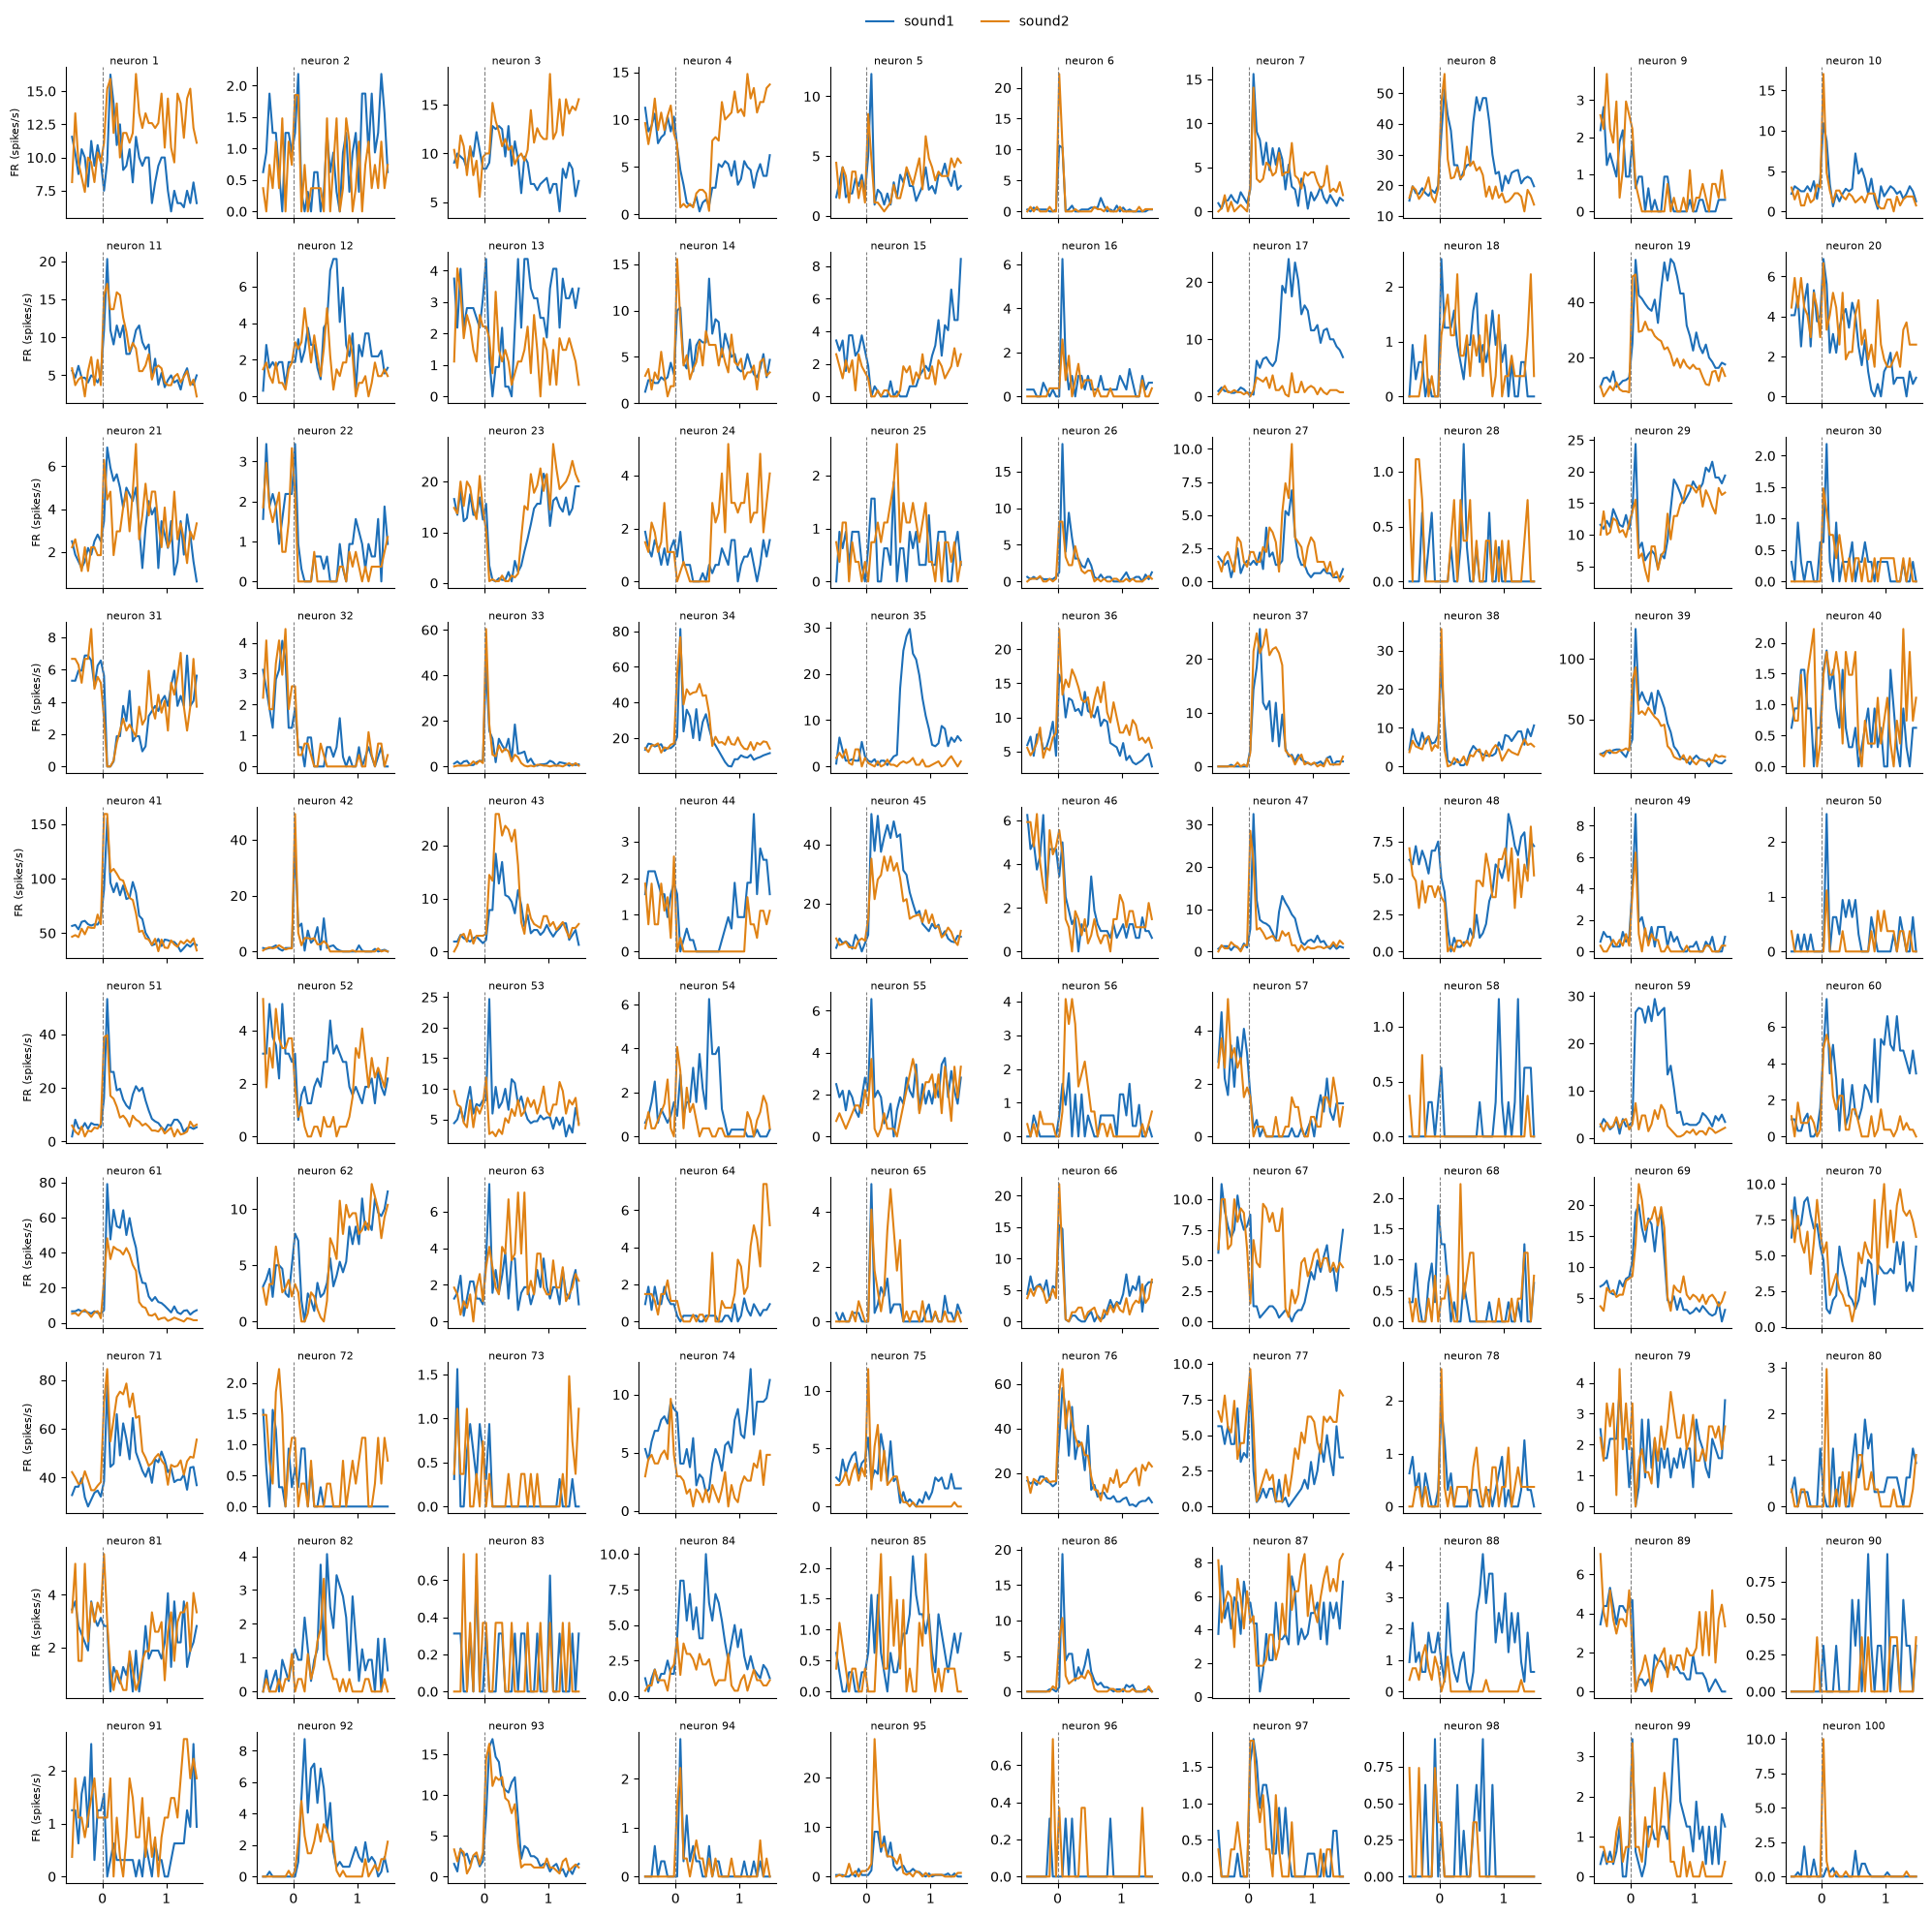

In [23]:
color_aud1 = '#1D6FB8'
color_aud2 = '#E08214'

# Pass your list or array of all 96 neuron indices here:
# e.g., all_neuron_indices = list(range(96)) or your filtered DataFrame indices
all_neuron_indices = np.arange(1,len(this_structure_units_table))
n_neurons = len(all_neuron_indices)

n_rows = 10
n_cols = 10

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(20, 20), sharex=True, sharey=False
)
axes_flat = axes.flatten()

for i, single_ax in enumerate(axes_flat):
    if i < n_neurons:
        neuron_idx = all_neuron_indices[i]

        # Plot PSTHs
        single_ax.plot(
            psth_bin_center_array,
            neuron_psth(neuron_idx, aud1_stim_time_array,bin_w),
            color=color_aud1,
            linewidth=1.5,
            label='sound1',
        )
        single_ax.plot(
            psth_bin_center_array,
            neuron_psth(neuron_idx, aud2_stim_time_array, bin_w),
            color=color_aud2,
            linewidth=1.5,
            label='sound2',
        )

        

        single_ax.axvline(0, color='0.5', linestyle='--', linewidth=0.8)
        single_ax.set_title(f'neuron {neuron_idx}', fontsize=8, pad=2)
        sns.despine(ax=single_ax)

        # Label only the leftmost column for y-axis
        if i % n_cols == 0:
            single_ax.set_ylabel('FR (spikes/s)', fontsize=8)

        # Label bottom row subplots for x-axis
        if i >= n_neurons - n_cols:
            single_ax.set_xlabel('time from onset (s)', fontsize=8)
    else:
        # Hide the remaining unused subplots (97 to 100)
        single_ax.axis('off')


# Shared legend at the top
handle_list, label_list = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handle_list,
    label_list,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    frameon=False,
    fontsize=10,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sound 1: 63 correct, 1 incorrect
Sound 2: 0 correct, 54 incorrect


/tmp/ipykernel_1859/1402738184.py:5: RuntimeWarning: Mean of empty slice
  return count_array.mean(axis=0) / bin_w
/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


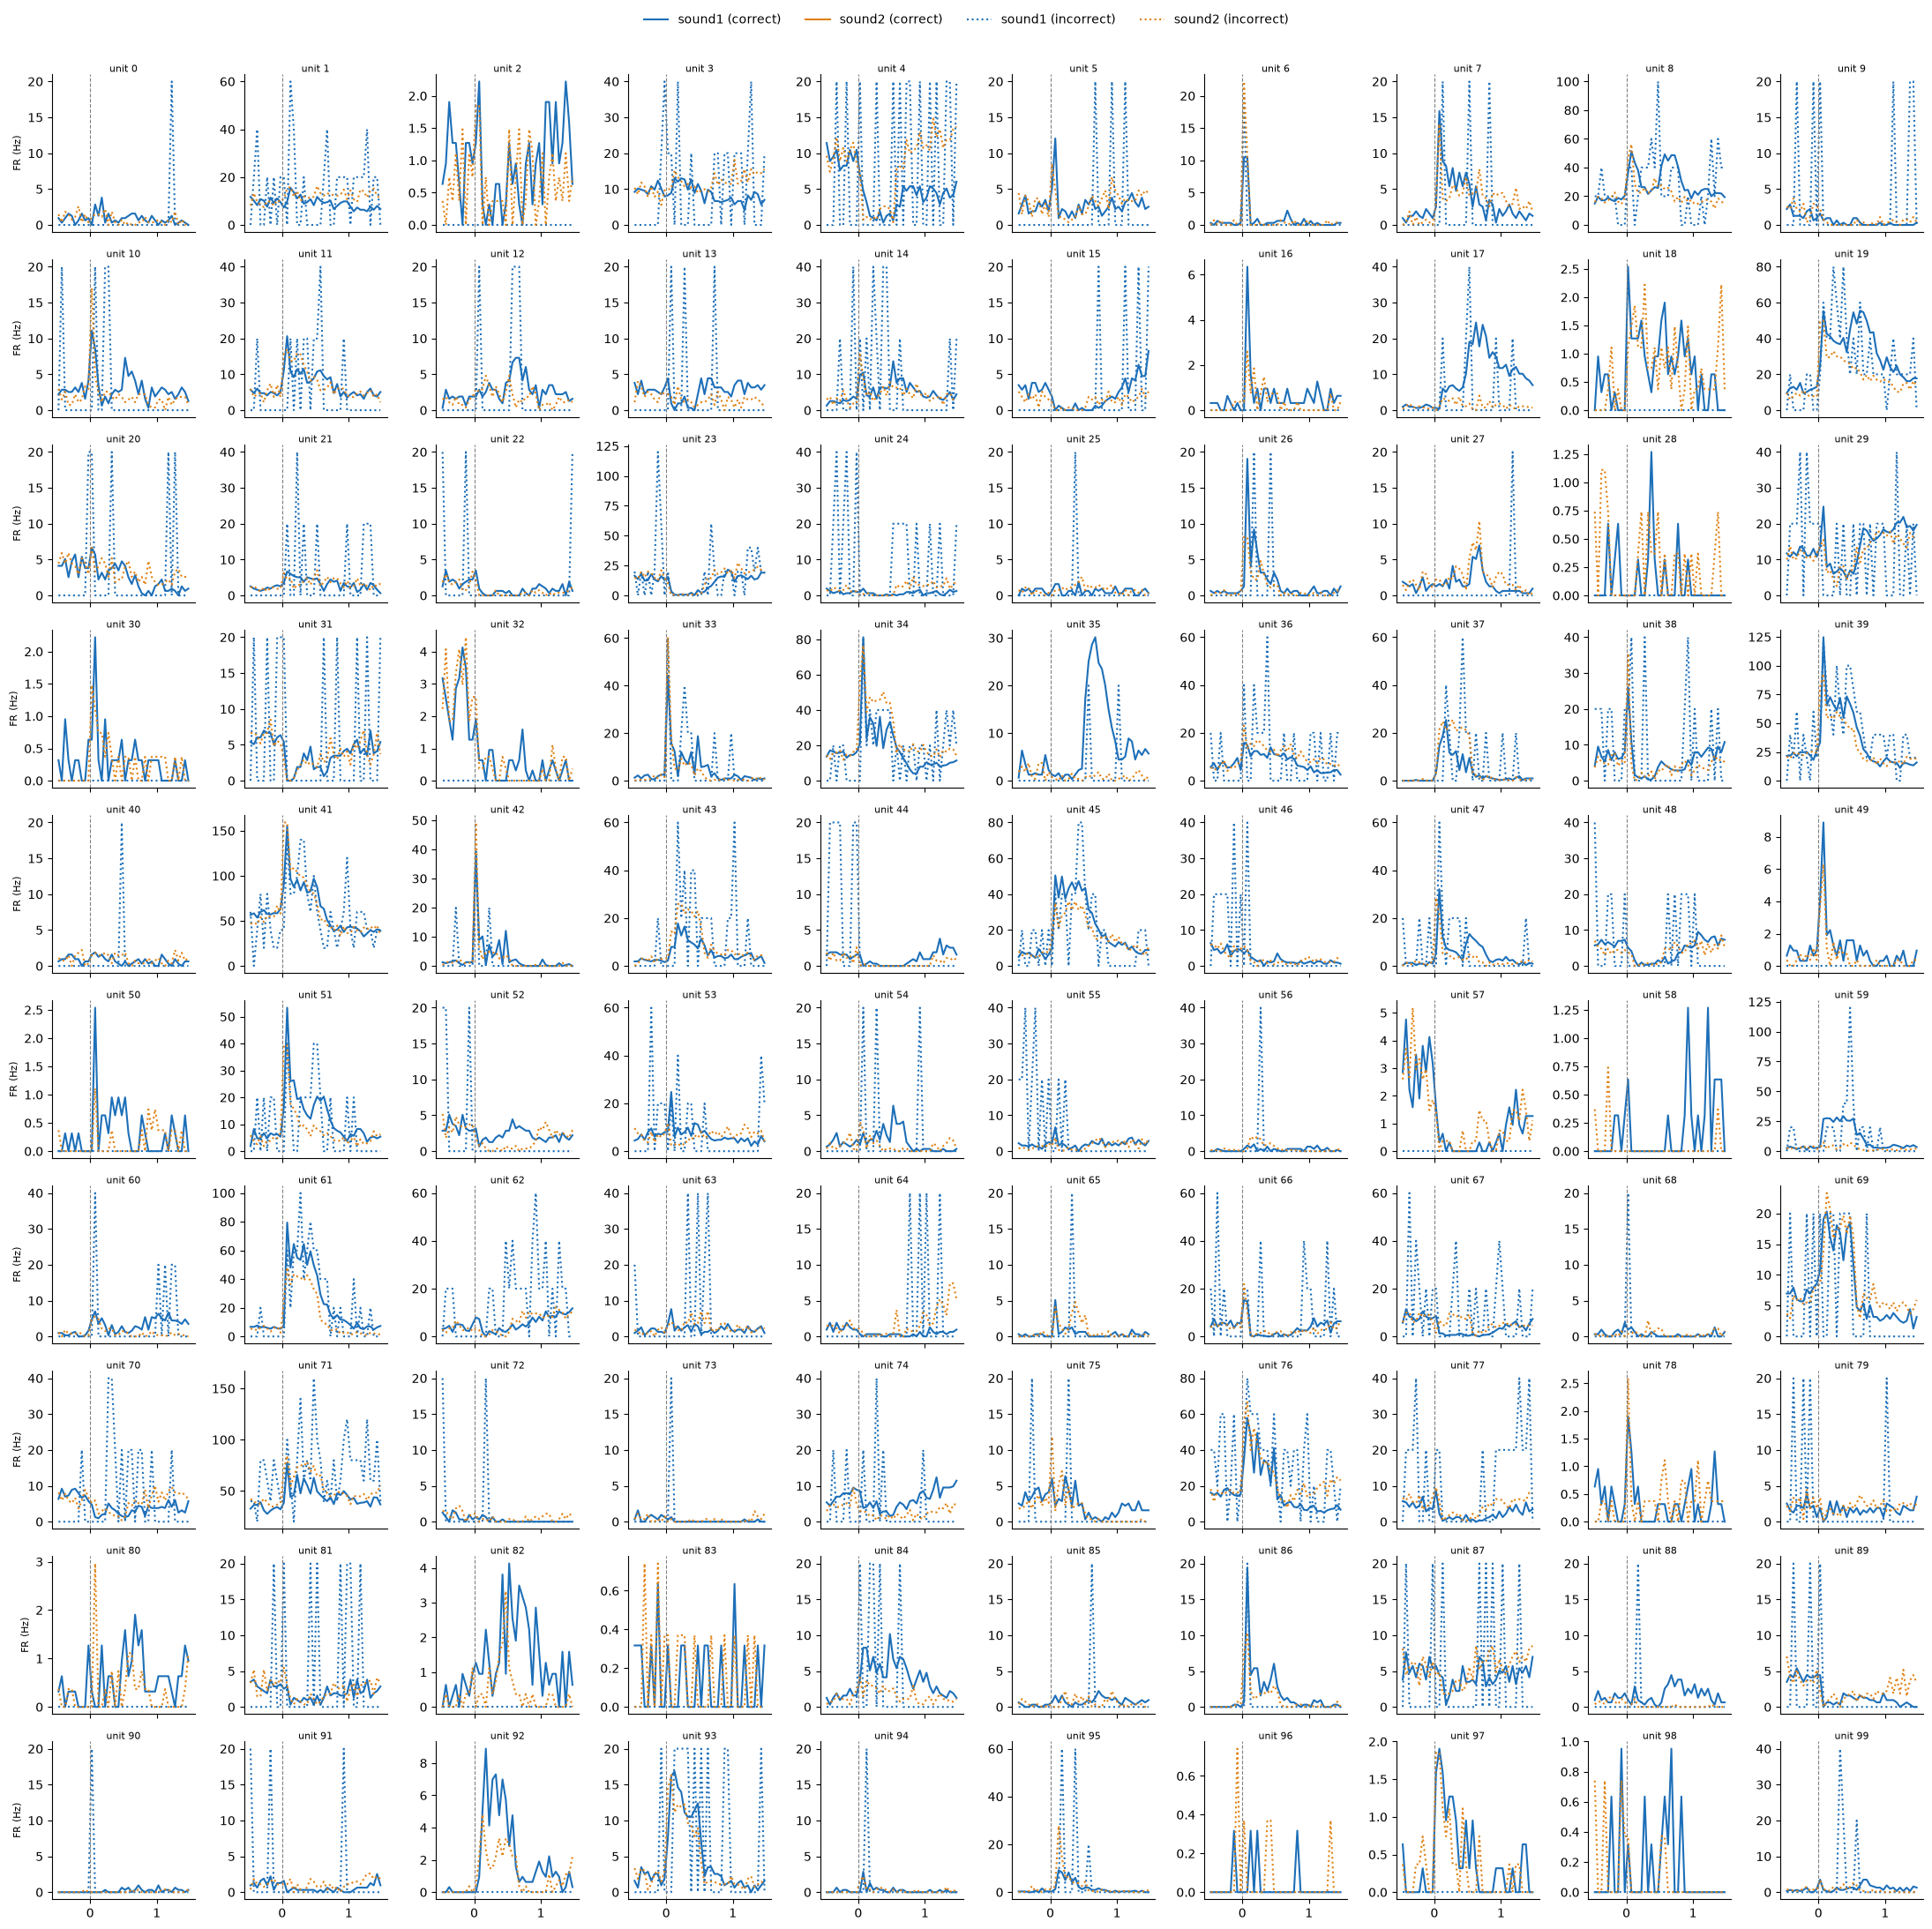

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract timestamps for Sound 1 (Correct vs Incorrect)
aud1_correct_times = trials.loc[
    (trials.stim_name == 'sound1')
    & (trials.rewarded_modality == 'aud')
    & (trials.is_rewarded == True),
    'stim_start_time',
].values

aud1_incorrect_times = trials.loc[
    (trials.stim_name == 'sound1')
    & (trials.rewarded_modality == 'aud')
    & (trials.is_rewarded == False),
    'stim_start_time',
].values

# 2. Extract timestamps for Sound 2 (Correct vs Incorrect)
aud2_correct_times = trials.loc[
    (trials.stim_name == 'sound2')
    & (trials.rewarded_modality == 'aud')
    & (trials.is_rewarded == True),
    'stim_start_time',
].values

aud2_incorrect_times = trials.loc[
    (trials.stim_name == 'sound2')
    & (trials.rewarded_modality == 'aud')
    & (trials.is_rewarded == False),
    'stim_start_time',
].values

print(
    f'Sound 1: {len(aud1_correct_times)} correct, {len(aud1_incorrect_times)} incorrect'
)
print(
    f'Sound 2: {len(aud2_correct_times)} correct, {len(aud2_incorrect_times)} incorrect'
)

# 3. Plotting setup
color_aud1 = '#1D6FB8'  # Blue
color_aud2 = '#E08214'  # Orange

n_neurons = len(this_structure_units_table)
n_rows, n_cols = 10, 10

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(22, 22), sharex=True, sharey=False
)
axes_flat = axes.flatten()

for i, single_ax in enumerate(axes_flat):
    if i < n_neurons:
        # Compute PSTHs
        psth_s1_corr = neuron_psth(i, aud1_correct_times, bin_w)
        psth_s2_corr = neuron_psth(i, aud2_correct_times, bin_w)

        # Plot Correct Trials (Solid)
        single_ax.plot(
            psth_bin_center_array,
            psth_s1_corr,
            color=color_aud1,
            linestyle='-',
            linewidth=1.5,
            label='sound1 (correct)',
        )
        single_ax.plot(
            psth_bin_center_array,
            psth_s2_corr,
            color=color_aud2,
            linestyle='-',
            linewidth=1.5,
            label='sound2 (correct)',
        )

        # Plot Incorrect Trials (Dotted) - checks if incorrect trials exist
        if len(aud1_incorrect_times) > 0:
            psth_s1_inc = neuron_psth(i, aud1_incorrect_times, bin_w)
            single_ax.plot(
                psth_bin_center_array,
                psth_s1_inc,
                color=color_aud1,
                linestyle=':',
                linewidth=1.5,
                label='sound1 (incorrect)',
            )

        if len(aud2_incorrect_times) > 0:
            psth_s2_inc = neuron_psth(i, aud2_incorrect_times, bin_w)
            single_ax.plot(
                psth_bin_center_array,
                psth_s2_inc,
                color=color_aud2,
                linestyle=':',
                linewidth=1.5,
                label='sound2 (incorrect)',
            )

        # Formatting
        single_ax.axvline(0, color='0.5', linestyle='--', linewidth=0.8)
        single_ax.set_title(f'unit {i}', fontsize=8, pad=2)
        sns.despine(ax=single_ax)

        if i % n_cols == 0:
            single_ax.set_ylabel('FR (Hz)', fontsize=8)

        if i >= n_neurons - n_cols:
            single_ax.set_xlabel('time (s)', fontsize=8)
    else:
        single_ax.axis('off')

# Shared legend at the top
handle_list, label_list = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handle_list,
    label_list,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=10,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [25]:
# 1. Identify sound-modulated units in the auditory cortex
# We evaluate response modulation by comparing stimulus-evoked firing rate (0.0 to 0.5 s)
# against pre-stimulus baseline (-0.5 to 0.0 s) across all sound trials.

resp_window = np.array([0.0, 0.5])
base_window = np.array([-0.5, 0.0])

n_units = len(this_structure_units_table)
n_trials = len(trials)
stim_times = trials['stim_start_time'].values

pop_counts_resp = np.zeros((n_trials, n_units))
pop_counts_base = np.zeros((n_trials, n_units))

for u_idx, spike_times in enumerate(this_structure_units_table.spike_times.values):
    pop_counts_resp[:, u_idx] = get_binned_triggered_spike_counts_fast(spike_times, stim_times, resp_window).flatten()
    pop_counts_base[:, u_idx] = get_binned_triggered_spike_counts_fast(spike_times, stim_times, base_window).flatten()

# Filter for sound presentation trials (sound1 or sound2)
sound_mask = trials['is_aud_stim'].values == True
sound_resp_mean = pop_counts_resp[sound_mask].mean(axis=0) / 0.5  # in Hz
sound_base_mean = pop_counts_base[sound_mask].mean(axis=0) / 0.5  # in Hz

resp_modulation = sound_resp_mean - sound_base_mean
std_diff = np.std((pop_counts_resp[sound_mask] - pop_counts_base[sound_mask]) / 0.5, axis=0) + 1e-5
sound_snr = resp_modulation / std_diff

# Rank units by sound responsiveness SNR
ranked_units_by_snr = np.argsort(np.abs(sound_snr))[::-1]
sound_modulated_units = ranked_units_by_snr[:8]

print(f"Total good ACx units: {n_units}")
print(f"Selected top {len(sound_modulated_units)} sound-modulated units: {sound_modulated_units.tolist()}")
for rank, u in enumerate(sound_modulated_units):
    print(f"  Rank {rank+1}: Unit {u} (ID: {this_structure_units_table.index[u]}) -> SNR = {sound_snr[u]:.2f}, Base FR = {sound_base_mean[u]:.1f} Hz, Evoked FR = {sound_resp_mean[u]:.1f} Hz")


Total good ACx units: 144
Selected top 8 sound-modulated units: [61, 39, 101, 45, 114, 19, 33, 37]
  Rank 1: Unit 61 (ID: 1314) -> SNR = 3.62, Base FR = 5.7 Hz, Evoked FR = 46.6 Hz
  Rank 2: Unit 39 (ID: 1270) -> SNR = 3.57, Base FR = 20.9 Hz, Evoked FR = 63.2 Hz
  Rank 3: Unit 101 (ID: 1669) -> SNR = 3.47, Base FR = 1.6 Hz, Evoked FR = 23.3 Hz
  Rank 4: Unit 45 (ID: 1280) -> SNR = 3.13, Base FR = 7.0 Hz, Evoked FR = 36.6 Hz
  Rank 5: Unit 114 (ID: 1710) -> SNR = 2.86, Base FR = 0.4 Hz, Evoked FR = 14.2 Hz
  Rank 6: Unit 19 (ID: 1213) -> SNR = 2.71, Base FR = 11.0 Hz, Evoked FR = 38.3 Hz
  Rank 7: Unit 33 (ID: 1246) -> SNR = 2.37, Base FR = 1.1 Hz, Evoked FR = 14.8 Hz
  Rank 8: Unit 37 (ID: 1261) -> SNR = 2.19, Base FR = 0.1 Hz, Evoked FR = 17.1 Hz


/tmp/ipykernel_1859/1402738184.py:5: RuntimeWarning: Mean of empty slice
  return count_array.mean(axis=0) / bin_w


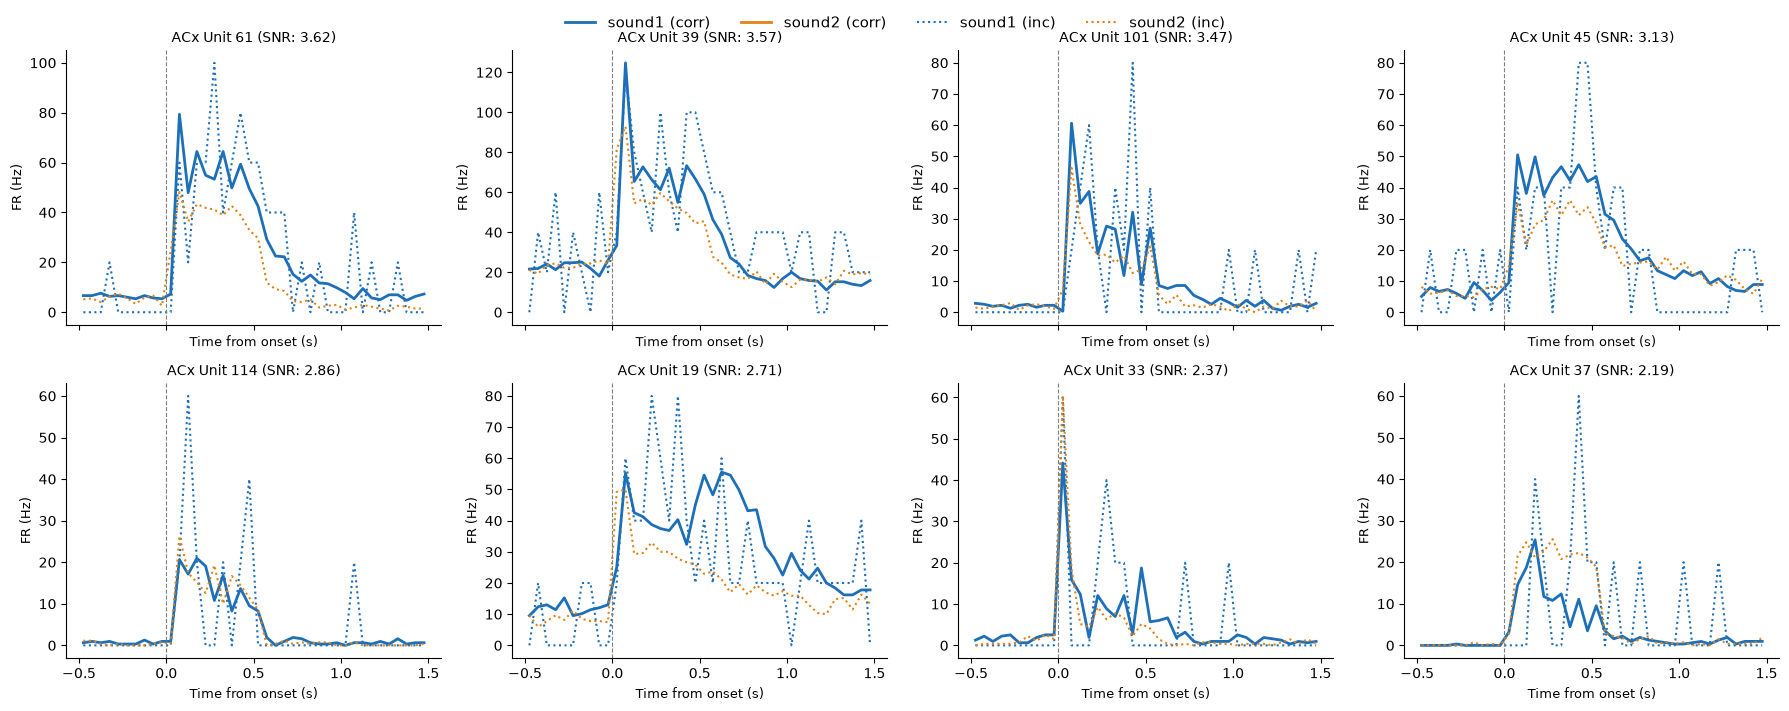

In [26]:
# Plot PSTHs of the selected top sound-modulated neurons for sound1 vs sound2 (correct vs incorrect)
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, sharey=False)
axes_flat = axes.flatten()

for i, unit_idx in enumerate(sound_modulated_units):
    ax = axes_flat[i]
    psth_s1_corr = neuron_psth(unit_idx, aud1_correct_times, bin_w)
    psth_s2_corr = neuron_psth(unit_idx, aud2_correct_times, bin_w)
    
    ax.plot(psth_bin_center_array, psth_s1_corr, color=color_aud1, linestyle='-', linewidth=2, label='sound1 (corr)')
    ax.plot(psth_bin_center_array, psth_s2_corr, color=color_aud2, linestyle='-', linewidth=2, label='sound2 (corr)')
    
    if len(aud1_incorrect_times) > 0:
        psth_s1_inc = neuron_psth(unit_idx, aud1_incorrect_times, bin_w)
        ax.plot(psth_bin_center_array, psth_s1_inc, color=color_aud1, linestyle=':', linewidth=1.5, label='sound1 (inc)')
    if len(aud2_incorrect_times) > 0:
        psth_s2_inc = neuron_psth(unit_idx, aud2_incorrect_times, bin_w)
        ax.plot(psth_bin_center_array, psth_s2_inc, color=color_aud2, linestyle=':', linewidth=1.5, label='sound2 (inc)')
        
    ax.axvline(0, color='0.5', linestyle='--', linewidth=0.8)
    ax.set_title(f'ACx Unit {unit_idx} (SNR: {sound_snr[unit_idx]:.2f})', fontsize=10)
    ax.set_ylabel('FR (Hz)', fontsize=9)
    ax.set_xlabel('Time from onset (s)', fontsize=9)
    sns.despine(ax=ax)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False, fontsize=11)
plt.tight_layout()
plt.show()
